# Explore here

In [2]:
import pandas as pd

url = "https://breathecode.herokuapp.com/asset/internal-link?id=413&path=bank-marketing-campaign-data.csv"
df = pd.read_csv(url, sep=";")

print(df.shape)
df.head()

(41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## 1) Setup for EDA
We import analysis and plotting libraries used to evaluate variable usefulness.

In [3]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")

## 2) Data quality and quick profile
We inspect missing values, `unknown` levels, duplicates, and class balance.

In [9]:
target_col = "y"

# Work on a copy for EDA decisions
df_eda = df.copy()

# In this dataset, "unknown" is semantically missing for many categoricals
obj_cols = df_eda.select_dtypes(include=["object", "string"]).columns
df_eda[obj_cols] = df_eda[obj_cols].replace("unknown", pd.NA)

print("Rows, columns:", df_eda.shape)
print("Duplicate rows:", df_eda.duplicated().sum())
print("Target distribution (%):")
print((df_eda[target_col].value_counts(normalize=True) * 100).round(2))

missing_pct = (df_eda.isna().mean() * 100).sort_values(ascending=False)
unknown_pct = (
    (df.astype(str) == "unknown").mean().sort_values(ascending=False) * 100
)

data_quality = pd.DataFrame({
    "dtype": df_eda.dtypes.astype(str),
    "missing_pct": missing_pct,
    "unknown_pct_raw": unknown_pct,
    "n_unique": df_eda.nunique(dropna=False)
}).sort_values("missing_pct", ascending=False)

data_quality.head(15)

Rows, columns: (41188, 21)
Duplicate rows: 12
Target distribution (%):
y
no     88.73
yes    11.27
Name: proportion, dtype: float64


,dtype,missing_pct,unknown_pct_raw,n_unique
default,str,20.872584,20.872584,3
education,str,4.202680,4.202680,8
housing,str,2.403613,2.403613,3
loan,str,2.403613,2.403613,3
job,str,0.801204,0.801204,12
marital,str,0.194231,0.194231,4
contact,str,0.000000,0.000000,2
cons.conf.idx,float64,0.000000,0.000000,26
campaign,int64,0.000000,0.000000,42
age,int64,0.000000,0.000000,78


## 3) Target and variable behavior
Visual checks help us see imbalance and potential numeric signal.

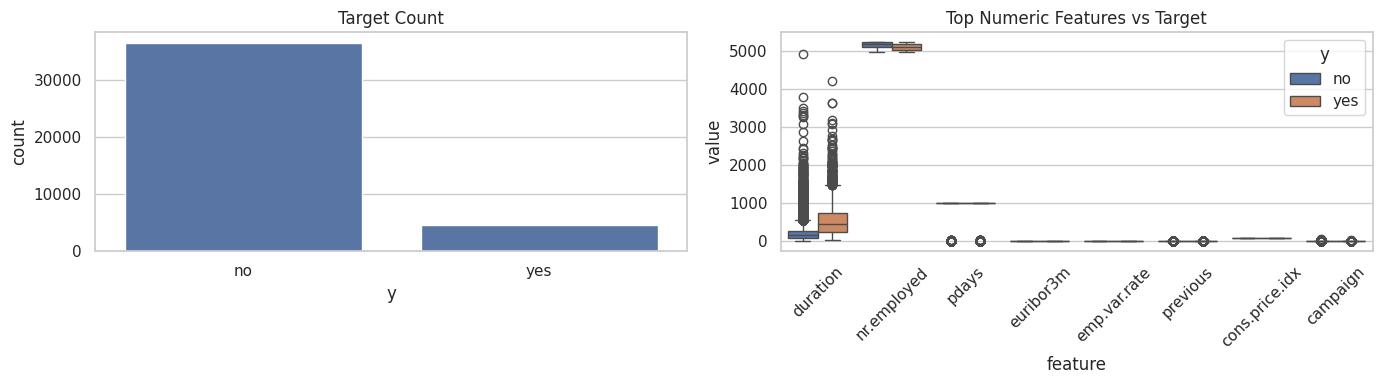

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.countplot(data=df_eda, x=target_col, ax=axes[0])
axes[0].set_title("Target Count")

numeric_cols = df_eda.select_dtypes(include=np.number).columns.tolist()
if len(numeric_cols) > 0:
    corr_to_target = (
        df_eda[numeric_cols]
        .assign(target_num=(df_eda[target_col] == "yes").astype(int))
        .corr(numeric_only=True)["target_num"]
        .drop("target_num")
        .abs()
        .sort_values(ascending=False)
    )
    top_num = corr_to_target.head(8).index.tolist()

    df_melt = df_eda[top_num + [target_col]].melt(
        id_vars=target_col, var_name="feature", value_name="value"
    )
    sns.boxplot(data=df_melt, x="feature", y="value", hue=target_col, ax=axes[1])
    axes[1].tick_params(axis="x", rotation=45)
    axes[1].set_title("Top Numeric Features vs Target")

plt.tight_layout()
plt.show()

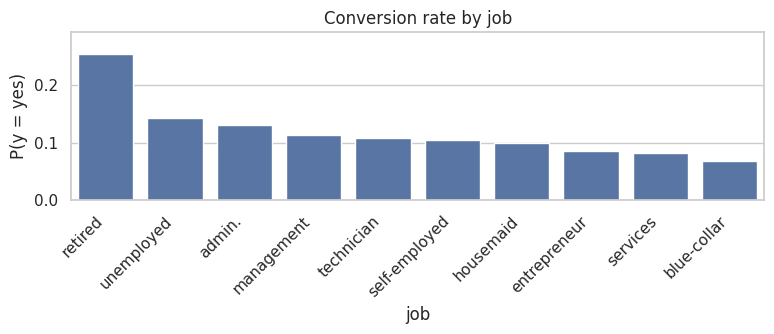

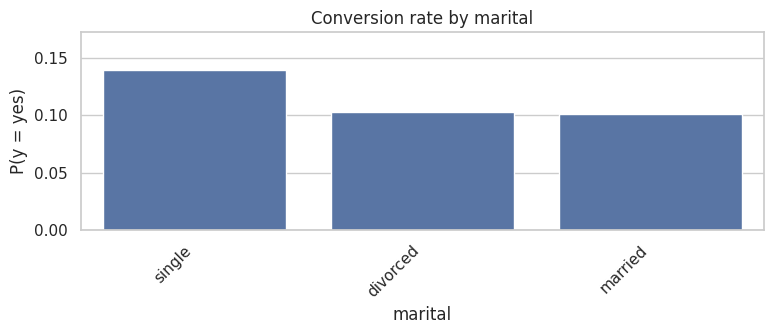

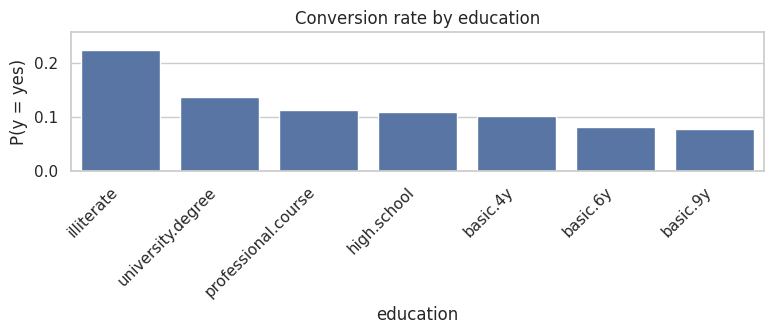

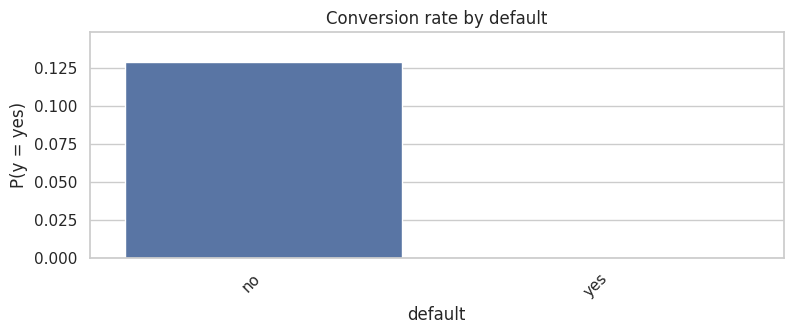

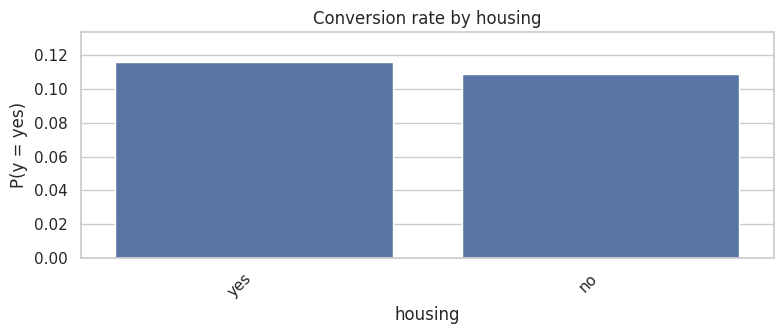

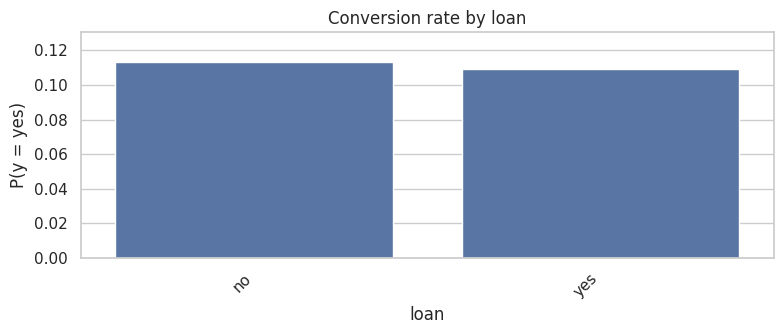

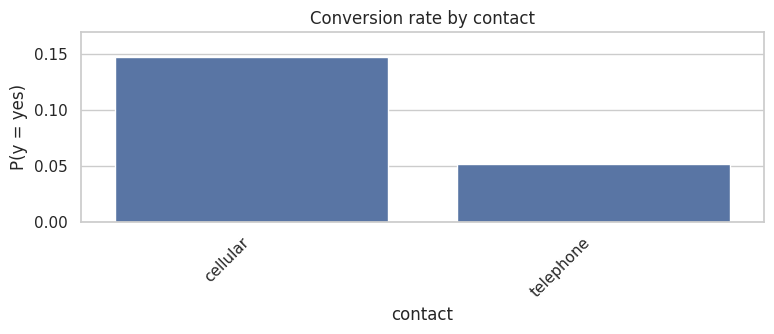

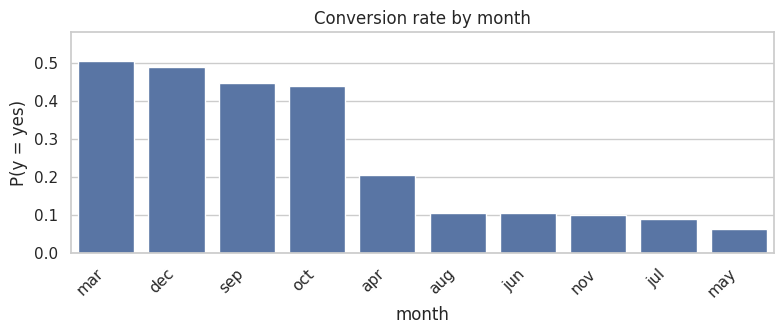

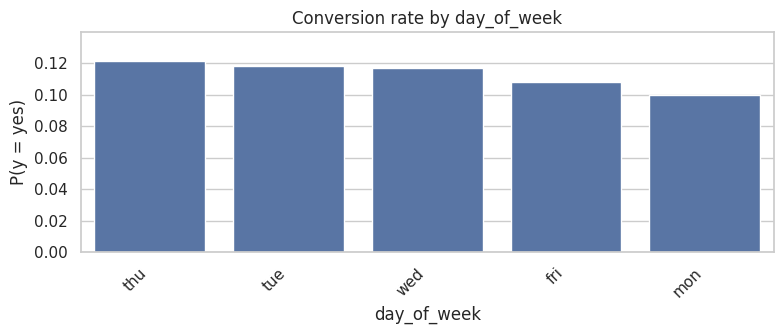

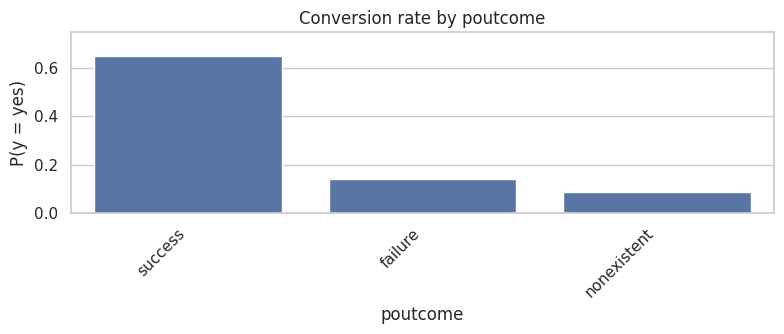

In [11]:
# Conversion rate by category (top 10 levels by frequency for each categorical feature)
cat_cols = [c for c in df_eda.select_dtypes(include=["object", "string"]).columns if c != target_col]

for col in cat_cols:
    top_levels = df_eda[col].value_counts(dropna=False).head(10).index
    summary = (
        df_eda[df_eda[col].isin(top_levels)]
        .groupby(col, dropna=False)[target_col]
        .apply(lambda s: (s == "yes").mean())
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(8, 3.5))
    sns.barplot(x=summary.index.astype(str), y=summary.values)
    plt.title(f"Conversion rate by {col}")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("P(y = yes)")
    plt.xlabel(col)
    plt.ylim(0, max(0.01, summary.max() * 1.15))
    plt.tight_layout()
    plt.show()

## 4) Relevance analysis and feature filtering
We score feature informativeness and define objective drop rules.

In [12]:
X_full = df_eda.drop(columns=[target_col]).copy()
y_full = (df_eda[target_col] == "yes").astype(int)

# One-hot encode so MI can score both numeric and categorical variables
X_encoded = pd.get_dummies(X_full, drop_first=False)
mi_scores = mutual_info_classif(
    X_encoded.fillna(-999),
    y_full,
    discrete_features="auto",
    random_state=42
)
mi_series = pd.Series(mi_scores, index=X_encoded.columns)

# Aggregate one-hot columns back to original feature names safely
orig_cols_sorted = sorted(X_full.columns.tolist(), key=len, reverse=True)

def get_base_feature(encoded_col: str) -> str:
    if encoded_col in X_full.columns:
        return encoded_col
    for c in orig_cols_sorted:
        if encoded_col.startswith(f"{c}_"):
            return c
    return encoded_col

base_feature_map = [get_base_feature(c) for c in X_encoded.columns]
feature_mi = (
    pd.DataFrame({"base_feature": base_feature_map, "mi": mi_series.values})
    .groupby("base_feature", as_index=True)["mi"]
    .max()
    .sort_values(ascending=False)
)

high_missing_cols = [c for c in X_full.columns if X_full[c].isna().mean() > 0.40]
constant_cols = [c for c in X_full.columns if X_full[c].nunique(dropna=False) <= 1]

# Domain rule: call duration is collected after the call and can leak target info
leakage_cols = ["duration"] if "duration" in X_full.columns else []

drop_cols = sorted(set(high_missing_cols + constant_cols + leakage_cols))
keep_cols = [c for c in X_full.columns if c not in drop_cols]

print("Top 15 features by mutual information:")
display(feature_mi.head(15).to_frame("mi_score"))

print("\nColumns flagged to drop:")
print(drop_cols if drop_cols else "None")
print(f"\nKept columns: {len(keep_cols)} | Dropped columns: {len(drop_cols)}")

Top 15 features by mutual information:


,mi_score
base_feature,
duration,0.078094
euribor3m,0.073189
cons.price.idx,0.070472
cons.conf.idx,0.069228
nr.employed,0.066387
emp.var.rate,0.055709
pdays,0.040891
poutcome,0.029801
contact,0.020425



Columns flagged to drop:
['duration']

Kept columns: 19 | Dropped columns: 1


## 5) Train/test split
We split after defining keep/drop columns and preserve class proportion with stratification.

In [13]:
X = df_eda[keep_cols].copy()
y = (df_eda[target_col] == "yes").astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train positive rate:", round(y_train.mean(), 4))
print("Test positive rate:", round(y_test.mean(), 4))

Train shape: (32950, 19)
Test shape: (8238, 19)
Train positive rate: 0.1127
Test positive rate: 0.1126


## 6) Final variable decisions
`drop_cols` contains variables considered non-informative or risky (for example leakage). `keep_cols` is the recommended modeling set.

In [14]:
decision_table = pd.DataFrame(
    {
        "feature": X_full.columns,
        "status": ["drop" if c in drop_cols else "keep" for c in X_full.columns],
        "reason": [
            "possible leakage" if c in leakage_cols
            else "high missing" if c in high_missing_cols
            else "constant" if c in constant_cols
            else "informative candidate"
            for c in X_full.columns
        ]
    }
)

display(decision_table.sort_values(["status", "feature"]))

,feature,status,reason
10,duration,drop,possible leakage
0,age,keep,informative candidate
11,campaign,keep,informative candidate
17,cons.conf.idx,keep,informative candidate
16,cons.price.idx,keep,informative candidate
7,contact,keep,informative candidate
9,day_of_week,keep,informative candidate
4,default,keep,informative candidate
3,education,keep,informative candidate
15,emp.var.rate,keep,informative candidate


## 7) Baseline logistic regression
This first model uses a default logistic regression definition and the current train/test split.

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Split feature types
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = [c for c in X_train.columns if c not in numeric_features]

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

baseline_logreg = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", LogisticRegression())
    ]
)

baseline_logreg.fit(X_train, y_train)

y_pred = baseline_logreg.predict(X_test)
y_proba = baseline_logreg.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 4))
print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=4))

Accuracy: 0.9011
ROC-AUC: 0.8008

Confusion matrix:
[[7220   90]
 [ 725  203]]

Classification report:
              precision    recall  f1-score   support

           0     0.9087    0.9877    0.9466      7310
           1     0.6928    0.2188    0.3325       928

    accuracy                         0.9011      8238
   macro avg     0.8008    0.6032    0.6395      8238
weighted avg     0.8844    0.9011    0.8774      8238



## 8) Optimize logistic regression
Since positive-class recall was low, we optimize with a class-weighted model and tune the decision threshold on a validation split.

In [16]:
from sklearn.metrics import f1_score, precision_recall_curve, precision_score, recall_score

# Keep test set untouched; create validation split from training data
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

optimized_logreg = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", LogisticRegression(class_weight="balanced", max_iter=1000))
    ]
)

optimized_logreg.fit(X_train_sub, y_train_sub)

# Tune threshold on validation set to maximize F1 for positive class
val_proba = optimized_logreg.predict_proba(X_val)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_val, val_proba)
f1_vals = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-12)
best_idx = int(np.argmax(f1_vals))
best_threshold = float(thresholds[best_idx])

# Evaluate optimized model on test set
opt_test_proba = optimized_logreg.predict_proba(X_test)[:, 1]
opt_test_pred = (opt_test_proba >= best_threshold).astype(int)

# Baseline comparison (threshold 0.50)
base_test_proba = baseline_logreg.predict_proba(X_test)[:, 1]
base_test_pred = (base_test_proba >= 0.50).astype(int)

comparison = pd.DataFrame(
    {
        "accuracy": [
            accuracy_score(y_test, base_test_pred),
            accuracy_score(y_test, opt_test_pred)
        ],
        "roc_auc": [
            roc_auc_score(y_test, base_test_proba),
            roc_auc_score(y_test, opt_test_proba)
        ],
        "precision_pos": [
            precision_score(y_test, base_test_pred, zero_division=0),
            precision_score(y_test, opt_test_pred, zero_division=0)
        ],
        "recall_pos": [
            recall_score(y_test, base_test_pred, zero_division=0),
            recall_score(y_test, opt_test_pred, zero_division=0)
        ],
        "f1_pos": [
            f1_score(y_test, base_test_pred, zero_division=0),
            f1_score(y_test, opt_test_pred, zero_division=0)
        ]
    },
    index=["baseline_default_threshold", "optimized_balanced_tuned_threshold"]
).round(4)

print(f"Best validation threshold by F1: {best_threshold:.4f}")
print("\nOptimized confusion matrix:")
print(confusion_matrix(y_test, opt_test_pred))
print("\nOptimized classification report:")
print(classification_report(y_test, opt_test_pred, digits=4))
print("\nBaseline vs optimized comparison:")
display(comparison)

Best validation threshold by F1: 0.6915

Optimized confusion matrix:
[[6739  571]
 [ 430  498]]

Optimized classification report:
              precision    recall  f1-score   support

           0     0.9400    0.9219    0.9309      7310
           1     0.4659    0.5366    0.4987       928

    accuracy                         0.8785      8238
   macro avg     0.7029    0.7293    0.7148      8238
weighted avg     0.8866    0.8785    0.8822      8238


Baseline vs optimized comparison:


,accuracy,roc_auc,precision_pos,recall_pos,f1_pos
baseline_default_threshold,0.9011,0.8008,0.6915,0.2198,0.3336
optimized_balanced_tuned_threshold,0.8785,0.8007,0.4659,0.5366,0.4987
